In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Türkçe karakterlerin düzgün görünmesi için grafik ayarları
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

# 1. Veri Setinin Tanımlanması
raw_data = {
    'Birim': [
        'Beyoğlu İtfaiye İstasyonu', 'Mecidiyeköy İtfaiye İstasyonu', 'Beşiktaş İtfaiye İstasyonu',
        'Ortaköy İtfaiye İstasyonu', 'Seyrantepe İtfaiye İstasyonu', 'İstinye İtfaiye İstasyonu',
        'Sarıyer İtfaiye İstasyonu', 'Şişli İtfaiye İstasyonu', 'Hacıosman İtfaiye İstasyonu',
        'Maden İtfaiye İstasyonu', 'Kemerburgaz İtfaiye İstasyonu', 'Kağıthane İtfaiye İstasyonu',
        'Sadabat İtfaiye İstasyonu', 'Bakırköy İtfaiye İstasyonu', 'Bayrampaşa İtfaiye İstasyonu',
        'Fatih İtfaiye İstasyonu', 'Florya İtfaiye İstasyonu', 'Zeytinburnu İtfaiye İstasyonu',
        'Davutpaşa İtfaiye İstasyonu', 'Eyüpsultan İtfaiye İstasyonu', 'Balat İtfaiye İstasyonu',
        'Eminönü İtfaiye İstasyonu', 'Kocamustafapaşa İtfaiye İstasyonu', 'Arnavutköy İtfaiye İstasyonu',
        'Bağcılar İtfaiye İstasyonu', 'Gaziosmanpaşa İtfaiye İstasyonu'
    ],
    'İlçe': [
        'Şişli', 'Şişli', 'Beşiktaş', 'Beşiktaş', 'Kağıthane', 'Sarıyer', 'Sarıyer', 'Şişli',
        'Sarıyer', 'Sarıyer', 'Eyüpsultan', 'Kağıthane', 'Kağıthane', 'Bakırköy', 'Bayrampaşa',
        'Fatih', 'Bakırköy', 'Zeytinburnu', 'Esenler', 'Eyüpsultan', 'Fatih', 'Fatih', 'Fatih',
        'Arnavutköy', 'Bağcılar', 'Gaziosmanpaşa'
    ],
    'Statü': [
        'Grup Amirliği', 'Müfreze Amirliği', 'Grup Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği',
        'Grup Amirliği', 'Grup Amirliği', 'Grup Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği',
        'Müfreze Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği', 'Grup Amirliği', 'Grup Amirliği',
        'Grup Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği',
        'Müfreze Amirliği', 'Müfreze Amirliği', 'Müfreze Amirliği', 'Grup Amirliği', 'Grup Amirliği', 'Müfreze Amirliği'
    ],
    'İstasyon Adresi': [
        'Harbiye Mh. Gümüş Sk. No:8 Şişli', 'Fulya Mh. Garaj Sk. No:12 Mecidiyeköy Şişli',
        'Yıldız Mh. Yıldız Park İçi Orhaniye Kapısı No:1 Beşiktaş', 'Arnavutköy Mh. Kireçhane Sk. No:34 Beşiktaş',
        'Seyrantepe Mh. İ.Karaosmanoğlu Cd. NO:52 Kağıthane', 'İstinye Cd. No:106 İstinye Sarıyer',
        'Büyükdere Mh. Maltızderesi Sk. No:15 Sarıyer', 'Halil Rıfat Paşa Mh. Taşkızak Cd. No:3 Şişli',
        'Büyükdere Cd. Hacıosman Boğaziçi İmar M...', 'Zekeriyaköy Mh. Kilyos Caddesi No:204 Sarıyer',
        'Mithatpaşa Mh. Selanik Blv. No:80 Kemerburgaz Eyüpsultan', 'Merkez Mh. Osmanpaşa Cd. İski İçi No:7 Kağıthane',
        'İmrahor Cd. Dolapdere Maçka Tünel Girişi Kağıthane', 'Koşuyolu Cd. No:45 Bakırköy',
        'Yahya Kemal Caddesi No:85-87 Bayrampaşa', 'Zeyrek Mh. İtfaiye Cd. No:9 Fatih',
        'Yeşilköy Mh. Yeşilköy Halkalı Cad. No:77 Bakırköy', 'Kazlı Çeşme Mh. Zübeyde Hanım Cad. No:4 Zeytinburnu',
        'Çiftehavuzlar Mh. Yıldız cad. No:95 Esenler', 'Rami Cuma Mh. Talimhane Cd. No:8 Rami Eyüpsultan',
        'Balat Mh. Ayvansaray Cad. Şair Nedim Parkı Fatih', 'Alemdar Mh. Çatal Çeşme Sk. 48 Eminönü Fatih',
        'Seyit Ömer Mah. Emrullah Efendi Sok. No:3 Fatih', 'Nenehatun Mah. Hasan Tahsin Cad. No:36 Arnavutköy',
        'Fevziçakmak Mahallesi Osmangazi Cd. No:1 Bağcılar', 'Barbaros Hayrettin Paşa Mh. 1058 Sk. No:46 Gaziosmanpaşa'
    ],
    'Boylam': [
        28.9888, 28.9982, 29.0125, 29.0401, 28.9812, 29.0531, 29.0384, 28.9662,
        29.0265, 29.0432, 28.9112, 28.9615, 28.9560, 28.8812, 28.8977, 28.9537,
        28.8079, 28.9121, 28.8948, 28.9194, 28.9520, 28.9763, 28.9341, 28.7288,
        28.8585, 28.8936
    ]
}

In [2]:
# 2. CSV Dosyasına Kaydetme ve Okuma
df_initial = pd.DataFrame(raw_data)
df_initial.to_csv('itfaiye_istasyon_konumlari.csv', index=False, encoding='utf-8-sig')

df = pd.read_csv('itfaiye_istasyon_konumlari.csv')

In [3]:
# 3. İstatistikler & Özet
print("--- İlçelere Göre İstasyon Sayısı ---")
ilce_counts = df['İlçe'].value_counts()
print(ilce_counts)

--- İlçelere Göre İstasyon Sayısı ---
İlçe
Sarıyer          4
Fatih            4
Şişli            3
Kağıthane        3
Beşiktaş         2
Eyüpsultan       2
Bakırköy         2
Bayrampaşa       1
Zeytinburnu      1
Esenler          1
Arnavutköy       1
Bağcılar         1
Gaziosmanpaşa    1
Name: count, dtype: int64


C:\Users\emirh\AppData\Local\Temp\ipykernel_912\3635999110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ilce_counts.index, y=ilce_counts.values, palette='Blues_r')


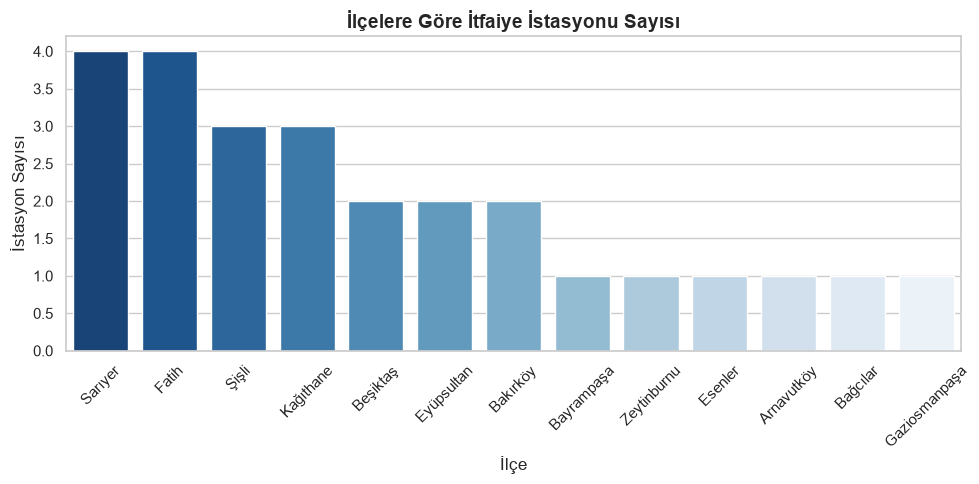

In [4]:
# 4. Görselleştirme (Sütun Grafiği)
plt.figure(figsize=(10, 5))
sns.barplot(x=ilce_counts.index, y=ilce_counts.values, palette='Blues_r')
plt.title('İlçelere Göre İtfaiye İstasyonu Sayısı', fontsize=14, fontweight='bold')
plt.xlabel('İlçe')
plt.ylabel('İstasyon Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()